<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Profissao_Cientista_de_Dados_M14_Pratique_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [42]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [43]:
#Lendo o csv e separando dados por ";"
df = pd.read_csv('/content/CHURN_TELECON_MOD08_TAREFA.csv', sep=';')
#Após uma primeira verificação, os dados estavam separados por ';' (SSV) e não por ',' (CSV), então foi adicionado o parâmetro "sep=''" para a correta separação das colunas

#Verificando informações da db
print(df.head())
print(df.info())


   customerID  Genero  Idoso Casado Dependents  Tempo_como_Cliente  \
0  7590-VHVEG  Female      0    Yes         No                   1   
1  5575-GNVDE    Male      0     No         No                  34   
2  3668-QPYBK    Male      0     No         No                   2   
3  7795-CFOCW    Male      0     No         No                  45   
4  9237-HQITU     NaN      0     No         No                   2   

  PhoneService Servico_Internet Servico_Seguranca Suporte_Tecnico StreamingTV  \
0           No              DSL                No              No          No   
1          Yes              DSL               Yes              No          No   
2          Yes              DSL               Yes              No          No   
3           No              DSL               Yes             Yes          No   
4          Yes      Fiber optic                No              No          No   

    Tipo_Contrato              PaymentMethod  Pagamento_Mensal  Total_Pago  \
0  Month-to-mo

In [44]:
#Corrigindo título das colunas
df = df.rename(columns={
    'Genero': 'gender',
    'Idoso' : 'elderly',
    'Casado': 'married',
    'Dependents': 'dependents',
    'Tempo_como_Cliente': 'tenure_months',
    'PhoneService': 'phone_service',
    'Servico_Internet': 'internet_service',
    'Servico_Seguranca': 'online_security',
    'Suporte_Tecnico': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'Tipo_Contrato': 'contract_type',
    'PaymentMethod': 'payment_method',
    'Pagamento_Mensal': 'monthly_charges',
    'Total_Pago': 'total_charges',
    'Churn': 'churn'
})

#Corrigindo categoria da variáveis

#Variáveis categóricas para category
category_cols = [
    'gender', 'internet_service',
    'contract_type', 'payment_method'
]

for col in category_cols:
    df[col] = df[col].astype('category')

#Variáveis numéricas para int e float
df['tenure_months'] = df['tenure_months'].astype('int64')
df['monthly_charges'] = df['monthly_charges'].astype('float64')
df['total_charges'] = df['total_charges'].astype('float64')

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [45]:
#Verificando dados faltantes
df.isna().sum()

#Calculando percentual de dados faltantes por colunas
missing_percentage = df.isna().sum() / len(df) * 100
print(missing_percentage)

customerID           0.00
gender               0.48
elderly              0.00
married              0.00
dependents           0.00
tenure_months        0.00
phone_service       59.28
internet_service     0.00
online_security      0.00
tech_support         0.00
streaming_tv         0.00
contract_type        0.00
payment_method       0.00
monthly_charges     13.00
total_charges        0.00
churn                0.20
dtype: float64


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

Como a coluna 'phone_service' possui mais da metade dos valores nulos, será necessário removê-la, visto que se preenchermos os valores nulos, podemos facilmente enviesar a análise.
Além disso, por termos um percentual muito baixo de valores nulos em 'gender' e 'churn', também podemos removê-los

In [46]:
#Removendo a coluna'phone_service' e os valores nulos em 'gender' e 'churn'
df = df.drop(['phone_service'], axis=1, errors='ignore')
df = df.dropna(subset=['gender'])
df = df.dropna(subset=['churn'])

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

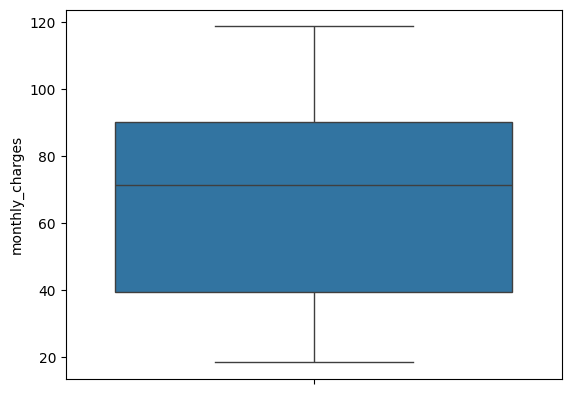

In [47]:
sns.boxplot(y=df['monthly_charges'])
plt.show()

#Substituindo os valores nulos de 'monthly_charges' pela mediana
df['monthly_charges'] = df['monthly_charges'].fillna(df['monthly_charges'].median())


Visto que os valores de 'monthly_charges' estão bem distribuidos, sem a presença de outliers como foi possível verificarno boxplot, faremos a substituição dos valores nulos pela mediana, uma vez que é o valor central dentro do conjunto de dados, causando o mínimo de viés possível.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [48]:
#seu código aqui

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [49]:
# Identificando e corrigindo valores inconsistentes

# Verificar valores únicos para colunas categóricas e booleanas para encontrar inconsistências
print("Verificando valores únicos nas colunas ANTES das correções:")
for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    print(f"  '{col}': {df[col].unique()}")


Verificando valores únicos nas colunas ANTES das correções:
  'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '5702-SKUOB' '1134-YWTYF'
 '6061-GWWAV']
  'gender': ['Female', 'Male', 'F', 'M', 'f']
Categories (5, object): ['F', 'Female', 'M', 'Male', 'f']
  'married': ['Yes' 'No']
  'dependents': ['No' 'Yes']
  'internet_service': ['DSL', 'No', 'Fiber optic', 'dsl']
Categories (4, object): ['DSL', 'Fiber optic', 'No', 'dsl']
  'online_security': ['No' 'Yes' 'No internet service']
  'tech_support': ['No' 'Yes' 'No internet service']
  'streaming_tv': ['No' 'No internet service' 'Yes']
  'contract_type': ['Month-to-month', 'One year', 'Two year']
Categories (3, object): ['Month-to-month', 'One year', 'Two year']
  'payment_method': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Categories (4, object): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check',
                         'Mailed check']
  'churn': ['No'

Será necessário padronizar os parâmetros de 'gender' e 'internet_service' para termos uma base com dados mais sólidos e categorias únicas bem definidas

In [52]:
# Correção para a coluna 'gender': substituir 'Female' por 'F' e 'Male' por 'M'
if 'Female' in df['gender'].unique():
    df['gender'] = df['gender'].replace('Female', 'F')
if 'f' in df['gender'].unique():
    df['gender'] = df['gender'].replace('f', 'F')
if 'Male' in df['gender'].unique():
    df['gender'] = df['gender'].replace('Male', 'M')


# Correção para a coluna 'internet_service': substituir 'dsl' por 'DSL'
if 'dsl' in df['internet_service'].unique():
    df['internet_service'] = df['internet_service'].replace('dsl', 'DSL')

# Re-verificar valores únicos após as correções para confirmar
print("\nVerificando valores únicos nas colunas APÓS as correções:")
for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    print(f"  '{col}': {df[col].unique()}")


Verificando valores únicos nas colunas APÓS as correções:
  'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '5702-SKUOB' '1134-YWTYF'
 '6061-GWWAV']
  'gender': ['F', 'M']
Categories (2, object): ['F', 'M']
  'married': ['Yes' 'No']
  'dependents': ['No' 'Yes']
  'internet_service': ['DSL', 'No', 'Fiber optic']
Categories (3, object): ['DSL', 'Fiber optic', 'No']
  'online_security': ['No' 'Yes' 'No internet service']
  'tech_support': ['No' 'Yes' 'No internet service']
  'streaming_tv': ['No' 'No internet service' 'Yes']
  'contract_type': ['Month-to-month', 'One year', 'Two year']
Categories (3, object): ['Month-to-month', 'One year', 'Two year']
  'payment_method': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Categories (4, object): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check',
                         'Mailed check']
  'churn': ['No' 'Yes']


/tmp/ipython-input-476718389.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['gender'] = df['gender'].replace('Female', 'F')
/tmp/ipython-input-476718389.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['gender'] = df['gender'].replace('f', 'F')
/tmp/ipython-input-476718389.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['gender'] = 

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.